In [1]:
import os
from pathlib import Path
import pandas as pd
import shapely
import geopandas as gpd
import matplotlib.pyplot as plt

# === Setup ===
import numpy as np
import matplotlib.patches as mpatches
import re
import xarray as xr

# Create multi-panel horizontal stacked bar plot
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
base_path  = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\MIRACA\MIRACA_results_exposure")
# Get all results
exposure_files = list(base_path .glob('*.parquet')) + list(base_path .glob('*.csv'))

In [3]:
# Define countries and base path
COUNTRIES = ['SVN', 'SVK', 'AUT', 'BEL', 'BGR', 'CHE', 'CYP', 
             'CZE', 'DEU', 'DNK', 'EST', 'GRC', 'ESP', 'FIN', 'FRA', 'HRV', 
             'HUN', 'IRL', 'ISL', 'ITA', 'LIE', 'LTU', 'LUX', 'LVA',  
             'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SWE']

INFRASTRUCTURE_TYPES = ["healthcare", "education", "power", "rail", "roads", "telecom"]
TEMPERATURE_THRESHOLDS = ["30C", "35C", "40C"]

In [ ]:
# Initialize dictionary to store dataframes for each infrastructure type
landslide_susceptibility_by_infra = {}

# Process each infrastructure type
for infra_type in INFRASTRUCTURE_TYPES:
    # Get all files for this infrastructure type and landslide hazard
    infra_files = []
    for country in COUNTRIES:
        file_path = base_path / f"{country}_{infra_type}_landslide_exposure.parquet"
        if file_path.exists():
            infra_files.append(file_path)
    
    if infra_files:  # Only process if files exist
        # Read and combine all data for this infrastructure type
        infra_data = []
        for file_path in infra_files:
            df = pd.read_parquet(file_path)
            country = file_path.stem.split('_')[0]
            df['country'] = country
            infra_data.append(df)
        
        # Combine all data
        infra_df = pd.concat(infra_data, ignore_index=True)
        
        # Create susceptibility class summary by country
        susceptibility_summary = infra_df.groupby(['country', 'max_susceptibility']).size().unstack(fill_value=0)
        
        # Ensure all countries are present (even if no data)
        susceptibility_summary = susceptibility_summary.reindex(COUNTRIES, fill_value=0)
        
        # Sort columns by susceptibility value
        susceptibility_summary = susceptibility_summary.sort_index(axis=1)
        
        # Store in dictionary
        landslide_susceptibility_by_infra[infra_type] = susceptibility_summary

In [ ]:
# Fill France power gap with average of other France sectors
france_other_sectors = []
for infra_type in ['healthcare', 'education', 'roads', 'power', 'rail' , 'telecom']:
    df = landslide_susceptibility_by_infra[infra_type]
    if 'FRA' in df.index:
        france_other_sectors.append(df.loc['FRA'])

if france_other_sectors:
    # Calculate average across other sectors
    france_avg = pd.DataFrame(france_other_sectors).mean()
    
    # Fill France power data
    landslide_susceptibility_by_infra['power'].loc['FRA'] = pd.DataFrame(france_other_sectors).mean()

In [ ]:
# Set style
sns.set_style("whitegrid")

# Sort countries based on healthcare class 1 percentage (descending)
if 'healthcare' in landslide_susceptibility_by_infra:
    healthcare_df = landslide_susceptibility_by_infra['healthcare']
    healthcare_pct = healthcare_df.div(healthcare_df.sum(axis=1), axis=0) * 100
    healthcare_pct = healthcare_pct.loc[healthcare_pct.sum(axis=1) > 0]
    
    # Add missing countries with 100% in class 1.0 before sorting
    missing_countries = [c for c in countries_with_data if c not in healthcare_pct.index]
    if missing_countries and healthcare_pct.columns.tolist():
        # Create dataframe for missing countries
        missing_df = pd.DataFrame(0, index=missing_countries, columns=healthcare_pct.columns)
        if 1.0 in healthcare_pct.columns:
            missing_df[1.0] = 100
        else:
            # If 1.0 doesn't exist, use first column
            missing_df.iloc[:, 0] = 100
        healthcare_pct = pd.concat([healthcare_pct, missing_df])
    
    # Sort by class 1.0 percentage (descending) - assuming 1.0 is the first/lowest susceptibility class
    if 1.0 in healthcare_pct.columns:
        countries_ordered = healthcare_pct.sort_values(by=1.0, ascending=False).index.tolist()
    else:
        # Fallback to first column if 1.0 doesn't exist
        countries_ordered = healthcare_pct.sort_values(by=healthcare_pct.columns[0], ascending=False).index.tolist()
else:
    # Fallback to alphabetical if no healthcare data
    countries_ordered = sorted(list(countries_with_data))

# Create subplots
fig, axes = plt.subplots(1, 6, figsize=(20, 14), sharey=True)

# Process each infrastructure type
legend_handles = None
legend_labels = None

for i, infra_type in enumerate(INFRASTRUCTURE_TYPES):
    if infra_type in landslide_susceptibility_by_infra:
        # Get data and convert to percentages
        df = landslide_susceptibility_by_infra[infra_type]
        df_pct = df.div(df.sum(axis=1), axis=0) * 100
        
        # Reindex to consistent country order, fill missing countries with 0
        df_pct = df_pct.reindex(countries_ordered, fill_value=0)
        
        # For countries with no data (all zeros), set 100% in class 1.0
        no_data_mask = df_pct.sum(axis=1) == 0
        if no_data_mask.any() and 1.0 in df_pct.columns:
            df_pct.loc[no_data_mask, 1.0] = 100
        
        # Create horizontal stacked bar plot
        df_pct.plot(kind='barh', stacked=True, ax=axes[i], 
                   colormap='viridis_r', width=0.8)
        
        axes[i].set_title(f'{infra_type.capitalize()}', fontsize=20, fontweight='bold')
        axes[i].set_xlabel('Percentage (%)', fontsize=18)
        axes[i].set_xlim(0, 100)
        axes[i].tick_params(axis='both', which='major', labelsize=16)
        
        # Only show y-label for first subplot
        if i == 0:
            axes[i].set_ylabel('Country', fontsize=18)
        else:
            axes[i].set_ylabel('')
        
        # Store legend info from first plot with data
        if legend_handles is None:
            legend_handles, legend_labels = axes[i].get_legend_handles_labels()
        
        # Remove individual legends
        axes[i].legend().remove()
    
    else:
        # No data for this infrastructure type
        axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', 
                    transform=axes[i].transAxes, fontsize=18)
        axes[i].set_title(f'{infra_type.capitalize()}', fontsize=20, fontweight='bold')

# Add horizontal legend above the plots
if legend_handles:
    fig.legend(legend_handles, legend_labels, loc='upper center', 
               bbox_to_anchor=(0.5, 0.92), ncol=len(legend_labels), 
               fontsize=18, frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Make room for legend
plt.show()

In [5]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Define countries and infrastructure types
COUNTRIES = ['SVN', 'SVK', 'AUT', 'BEL', 'BGR', 'CHE', 'CYP', 
             'CZE', 'DEU', 'DNK', 'EST', 'GRC', 'ESP', 'FIN', 'FRA', 'HRV', 
             'HUN', 'IRL', 'ISL', 'ITA', 'LIE', 'LTU', 'LUX', 'LVA',  
             'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SWE']

INFRASTRUCTURE_TYPES = ["healthcare", "education", "power", "rail", "roads", "telecom"]

base_path = Path("C:/Users/eks510/OneDrive - Vrije Universiteit Amsterdam/2_Projects/MIRACA/MIRACA_results_exposure/")

# Define the columns we're interested in
wildfire_columns = {
    'rcp45_mid': 'abs_change_wildfire_rcp_4_5_recent_to_mid_future_mean',
    'rcp45_far': 'abs_change_wildfire_rcp_4_5_recent_to_far_future_mean',
    'rcp85_mid': 'abs_change_wildfire_rcp_8_5_recent_to_mid_future_mean',
    'rcp85_far': 'abs_change_wildfire_rcp_8_5_recent_to_far_future_mean'
}

# Initialize dictionaries to store data for each RCP scenario
wildfire_data_rcp45 = {}
wildfire_data_rcp85 = {}

# First pass: collect all data and calculate country averages across all sectors
all_country_data = []

for infra_type in INFRASTRUCTURE_TYPES:
    # Get all wildfire files for this infrastructure type
    infra_files = []
    for country in COUNTRIES:
        file_path = base_path / f"{country}_{infra_type}_wildfire_exposure.parquet"
        if file_path.exists():
            infra_files.append(file_path)
    
    if infra_files:  # Only process if files exist
        # Read and combine all data for this infrastructure type
        infra_data = []
        for file_path in infra_files:
            df = pd.read_parquet(file_path)
            
            # Handle the unnamed geometry column
            if '' in df.columns:
                df = df.rename(columns={'': 'geometry'})
            
            country = file_path.stem.split('_')[0]
            df['country'] = country
            df['infrastructure_type'] = infra_type
            infra_data.append(df)
        
        # Combine all data for this infrastructure type
        infra_df = pd.concat(infra_data, ignore_index=True)
        all_country_data.append(infra_df)

# Combine all data across all infrastructure types
if all_country_data:
    all_data = pd.concat(all_country_data, ignore_index=True)
    
    # Calculate overall country averages across all infrastructure types (ignoring negative values)
    country_overall_averages = {}
    for col in wildfire_columns.values():
        # Only average positive values for each country across all infrastructure types
        country_overall_averages[col] = all_data[all_data[col] > 0].groupby('country')[col].mean()
    
    country_overall_averages = pd.DataFrame(country_overall_averages)
    
    # Second pass: Process each infrastructure type and fill gaps
    for infra_type in INFRASTRUCTURE_TYPES:
        # Get all wildfire files for this infrastructure type
        infra_files = []
        for country in COUNTRIES:
            file_path = base_path / f"{country}_{infra_type}_wildfire_exposure.parquet"
            if file_path.exists():
                infra_files.append(file_path)
        
        if infra_files:  # Only process if files exist
            # Read and combine all data for this infrastructure type
            infra_data = []
            for file_path in infra_files:
                df = pd.read_parquet(file_path)
                
                # Handle the unnamed geometry column
                if '' in df.columns:
                    df = df.rename(columns={'': 'geometry'})
                
                country = file_path.stem.split('_')[0]
                df['country'] = country
                infra_data.append(df)
            
            # Combine all data
            infra_df = pd.concat(infra_data, ignore_index=True)
            
            # Calculate country averages for each scenario/time period (ignoring negative values)
            country_averages = {}
            for col in wildfire_columns.values():
                # Only average positive values for each country
                country_averages[col] = infra_df[infra_df[col] > 0].groupby('country')[col].mean()
            
            country_averages = pd.DataFrame(country_averages)
            
            # Fill gaps with overall country averages
            for country in country_overall_averages.index:
                if country not in country_averages.index:
                    # Add missing country with overall average values
                    country_averages.loc[country] = country_overall_averages.loc[country]
            
            # Create dataframes for RCP 4.5 and RCP 8.5
            rcp45_df = pd.DataFrame({
                'Mid Future (2040-2060)': country_averages[wildfire_columns['rcp45_mid']],
                'Far Future (2080-2100)': country_averages[wildfire_columns['rcp45_far']]
            })
            
            rcp85_df = pd.DataFrame({
                'Mid Future (2040-2060)': country_averages[wildfire_columns['rcp85_mid']],
                'Far Future (2080-2100)': country_averages[wildfire_columns['rcp85_far']]
            })
            
            # Store in dictionaries
            wildfire_data_rcp45[infra_type] = rcp45_df
            wildfire_data_rcp85[infra_type] = rcp85_df

In [6]:
from tqdm import tqdm
tqdm.pandas()
all_data.geometry = all_data.geometry.progress_apply(lambda x: shapely.from_wkb(x).centroid)

100%|███████████████████████████████████████████████████████████████████| 36950216/36950216 [13:18<00:00, 46275.95it/s]


In [7]:
all_data = gpd.GeoDataFrame(all_data)

In [12]:
fire_susceptibility = xr.open_dataset(
    r"C:\Data\CLC\DATA\fire_susceptibility.tif",
    engine="rasterio",
)

import rasterio

In [11]:
all_data = all_data.set_crs(4326).to_crs(3035)

In [14]:
with rasterio.open(r"C:\Data\CLC\DATA\fire_susceptibility.tif") as src:
    
    coords = [(geom.x, geom.y) for geom in all_data.geometry]
    
    # Process in batches
    batch_size = 100_000
    results = []
    
    for i in tqdm(range(0, len(coords), batch_size), desc="Sampling"):
        batch = coords[i:i + batch_size]
        values = [val[0] for val in src.sample(batch)]
        results.extend(values)
    
    all_data["fire_susceptibility"] = results

Sampling: 100%|██████████████████████████████████████████████████████████████████████| 370/370 [36:54<00:00,  5.98s/it]


In [16]:
all_data_susc = all_data[all_data["fire_susceptibility"] >= 2]

In [26]:
# Calculate overall country averages across all infrastructure types (ignoring negative values)
country_overall_averages = {}
for col in wildfire_columns.values():
    country_overall_averages[col] = all_data_susc[all_data_susc[col] > 0].groupby('country')[col].mean()
country_overall_averages = pd.DataFrame(country_overall_averages)

# Process each infrastructure type from the already-filtered data
wildfire_data_rcp45 = {}
wildfire_data_rcp85 = {}

for infra_type in INFRASTRUCTURE_TYPES:
    # Filter for this infrastructure type
    infra_df = all_data_susc[all_data_susc['infrastructure_type'] == infra_type]
    
    if len(infra_df) > 0:
        # Calculate country averages for each scenario/time period (ignoring negative values)
        country_averages = {}
        for col in wildfire_columns.values():
            country_averages[col] = infra_df[infra_df[col] > 0].groupby('country')[col].mean()
        
        country_averages = pd.DataFrame(country_averages)
        
        # Fill gaps with overall country averages
        for country in country_overall_averages.index:
            if country not in country_averages.index:
                country_averages.loc[country] = country_overall_averages.loc[country]
        
        # Create dataframes for RCP 4.5 and RCP 8.5
        wildfire_data_rcp45[infra_type] = pd.DataFrame({
            'Mid Future (2040-2060)': country_averages[wildfire_columns['rcp45_mid']],
            'Far Future (2080-2100)': country_averages[wildfire_columns['rcp45_far']]
        })
        
        wildfire_data_rcp85[infra_type] = pd.DataFrame({
            'Mid Future (2040-2060)': country_averages[wildfire_columns['rcp85_mid']],
            'Far Future (2080-2100)': country_averages[wildfire_columns['rcp85_far']]
        })

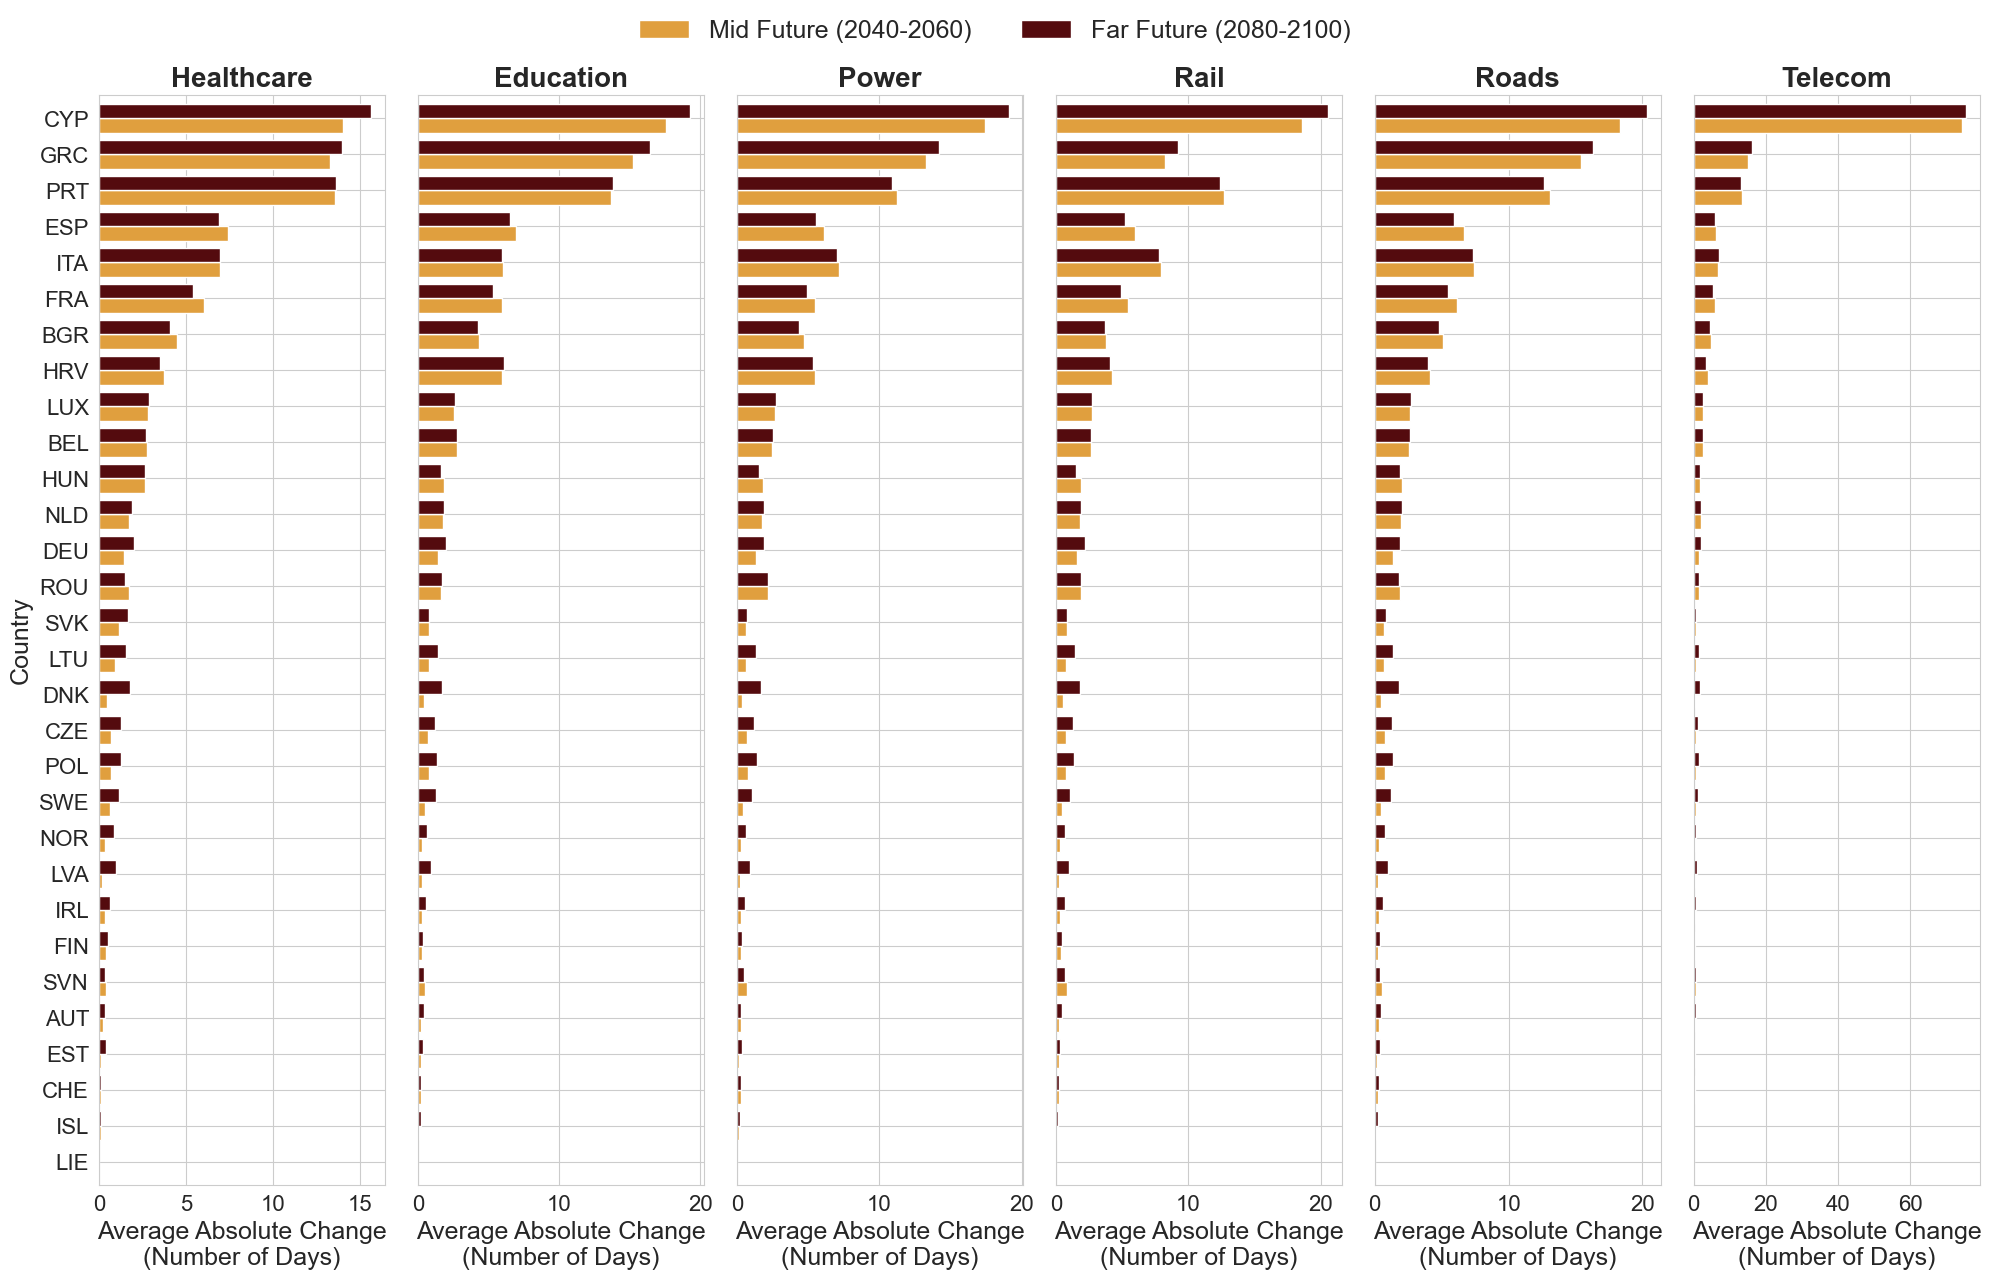

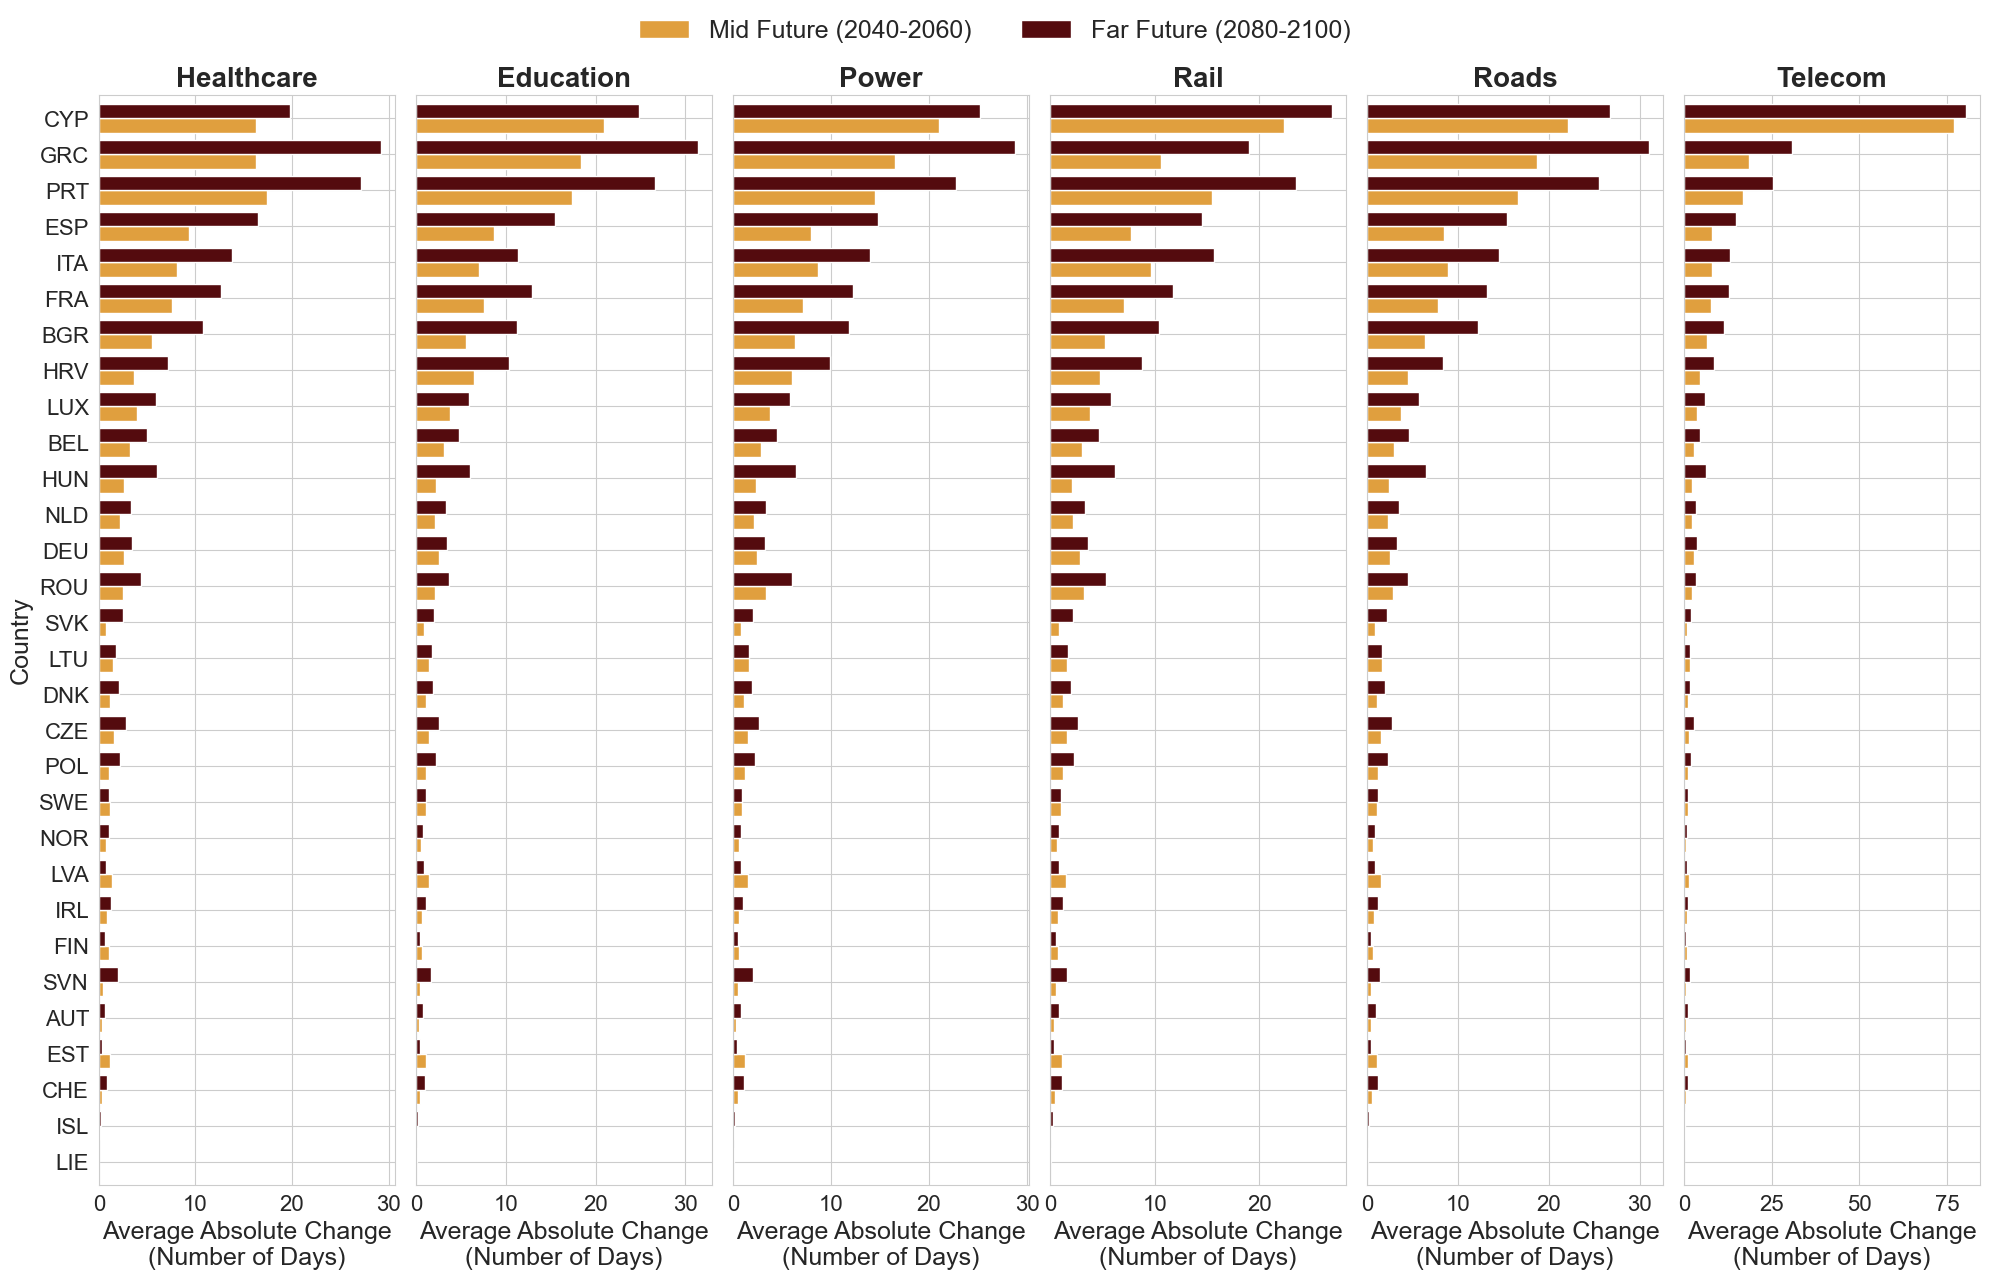

In [27]:
# Function to create the multi-panel plot
def create_wildfire_plot(data_dict, scenario_name, countries_ordered=None):
    """Create multi-panel plot for wildfire exposure changes"""
    
    # If no country order provided, determine from data
    if countries_ordered is None:
        countries_with_data = set()
        for infra_type in INFRASTRUCTURE_TYPES:
            if infra_type in data_dict:
                countries_with_data.update(data_dict[infra_type].index)
        countries_ordered = sorted(list(countries_with_data))
    
    # Set style
    sns.set_style("whitegrid")
    
    # Create subplots
    fig, axes = plt.subplots(1, 6, figsize=(20, 14), sharey=True)
    
    # Store legend info
    legend_handles = None
    legend_labels = None
    
    for i, infra_type in enumerate(INFRASTRUCTURE_TYPES):
        if infra_type in data_dict:
            # Get data and reindex to consistent country order
            df = data_dict[infra_type]
            df = df.reindex(countries_ordered, fill_value=0)
            
            # Create horizontal bar plot
            df.plot(kind='barh', ax=axes[i], width=0.8, 
                   color=['#e09f3e', '#540b0e'])  # Orange for mid, dark red for far
            
            axes[i].set_title(f'{infra_type.capitalize()}', fontsize=20, fontweight='bold')
            axes[i].set_xlabel('Average Absolute Change\n(Number of Days)', fontsize=18)
            axes[i].tick_params(axis='both', which='major', labelsize=16)
            
            # Only show y-label for first subplot
            if i == 0:
                axes[i].set_ylabel('Country', fontsize=18)
            else:
                axes[i].set_ylabel('')
            
            # Store legend info from first plot with data
            if legend_handles is None:
                legend_handles, legend_labels = axes[i].get_legend_handles_labels()
            
            # Remove individual legends
            axes[i].legend().remove()
        
        else:
            # No data for this infrastructure type
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', 
                        transform=axes[i].transAxes, fontsize=18)
            axes[i].set_title(f'{infra_type.capitalize()}', fontsize=20, fontweight='bold')
    
    # Add horizontal legend above the plots
    if legend_handles:
        fig.legend(legend_handles, legend_labels, loc='upper center', 
                   bbox_to_anchor=(0.5, 0.92), ncol=len(legend_labels), 
                   fontsize=18, frameon=False)
    
    # plt.suptitle(f'Wildfire Exposure Changes - {scenario_name}', 
    #              fontsize=22, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    
    # Save the plot
    plt.savefig(f'wildfire_exposure_{scenario_name.replace(" ", "_").replace(".", "")}.png', 
                dpi=300, bbox_inches='tight')
    plt.show()

# Determine consistent country ordering based on healthcare total exposure (small to large)
all_countries = set()
for scenario_data in [wildfire_data_rcp45, wildfire_data_rcp85]:
    for infra_type in INFRASTRUCTURE_TYPES:
        if infra_type in scenario_data:
            all_countries.update(scenario_data[infra_type].index)

# Sort based on healthcare total exposure (sum of mid + far future) for RCP 4.5
if 'healthcare' in wildfire_data_rcp45:
    healthcare_totals = wildfire_data_rcp45['healthcare'].sum(axis=1)
    countries_ordered = healthcare_totals.sort_values(ascending=True).index.tolist()
    
    # Add any countries not in healthcare data
    remaining_countries = sorted([c for c in all_countries if c not in countries_ordered])
    countries_ordered.extend(remaining_countries)
else:
    # Fallback to alphabetical if no healthcare data
    countries_ordered = sorted(list(all_countries))

# Create plots for both scenarios
create_wildfire_plot(wildfire_data_rcp45, "RCP 4.5", countries_ordered)
create_wildfire_plot(wildfire_data_rcp85, "RCP 8.5", countries_ordered)

In [ ]:
# Define the columns we're interested in

TEMPERATURE_THRESHOLDS = ["30C", "35C", "40C"]

heat_columns = {
    # RCP 4.5
    'rcp45_30C_mid': 'abs_change_30C_rcp_4_5_recent_to_mid_future_mean',
    'rcp45_30C_distant': 'abs_change_30C_rcp_4_5_recent_to_distant_future_mean',
    'rcp45_35C_mid': 'abs_change_35C_rcp_4_5_recent_to_mid_future_mean',
    'rcp45_35C_distant': 'abs_change_35C_rcp_4_5_recent_to_distant_future_mean',
    'rcp45_40C_mid': 'abs_change_40C_rcp_4_5_recent_to_mid_future_mean',
    'rcp45_40C_distant': 'abs_change_40C_rcp_4_5_recent_to_distant_future_mean',
    # RCP 8.5
    'rcp85_30C_mid': 'abs_change_30C_rcp_8_5_recent_to_mid_future_mean',
    'rcp85_30C_distant': 'abs_change_30C_rcp_8_5_recent_to_distant_future_mean',
    'rcp85_35C_mid': 'abs_change_35C_rcp_8_5_recent_to_mid_future_mean',
    'rcp85_35C_distant': 'abs_change_35C_rcp_8_5_recent_to_distant_future_mean',
    'rcp85_40C_mid': 'abs_change_40C_rcp_8_5_recent_to_mid_future_mean',
    'rcp85_40C_distant': 'abs_change_40C_rcp_8_5_recent_to_distant_future_mean'
}

# Initialize dictionaries to store data for each RCP scenario
heat_data_rcp45 = {}
heat_data_rcp85 = {}

# First pass: collect all data and calculate country averages across all sectors
all_country_heat_data = []

for infra_type in INFRASTRUCTURE_TYPES:
    if infra_type == 'roads':
        continue
    
    # Get all heat files for this infrastructure type
    infra_files = []
    for country in COUNTRIES:
        file_path = base_path / f"{country}_{infra_type}_heat_exposure.parquet"
        if file_path.exists():
            infra_files.append(file_path)
    
    if infra_files:  # Only process if files exist
        # Read and combine all data for this infrastructure type
        infra_data = []
        for file_path in infra_files:
            df = pd.read_parquet(file_path)
            
            # Handle the unnamed geometry column
            if '' in df.columns:
                df = df.rename(columns={'': 'geometry'})
            
            country = file_path.stem.split('_')[0]
            df['country'] = country
            df['infrastructure_type'] = infra_type
            infra_data.append(df)
        
        # Combine all data for this infrastructure type
        infra_df = pd.concat(infra_data, ignore_index=True)
        all_country_heat_data.append(infra_df)

# Combine all data across all infrastructure types
if all_country_heat_data:
    all_heat_data = pd.concat(all_country_heat_data, ignore_index=True)
    
    # Calculate overall country averages across all infrastructure types (ignoring negative values)
    country_overall_heat_averages = {}
    for col in heat_columns.values():
        if col in all_heat_data.columns:
            # Only average positive values for each country across all infrastructure types
            country_overall_heat_averages[col] = all_heat_data[all_heat_data[col] > 0].groupby('country')[col].mean()
    
    country_overall_heat_averages = pd.DataFrame(country_overall_heat_averages)

    # Second pass: Process each infrastructure type and fill gaps
    for infra_type in INFRASTRUCTURE_TYPES:
        if infra_type == 'roads':
            continue
        
        # Get all heat files for this infrastructure type
        infra_files = []
        for country in COUNTRIES:
            file_path = base_path / f"{country}_{infra_type}_heat_exposure.parquet"
            if file_path.exists():
                infra_files.append(file_path)
        
        if infra_files:  # Only process if files exist
            # Read and combine all data for this infrastructure type
            infra_data = []
            for file_path in infra_files:
                df = pd.read_parquet(file_path)
                
                # Handle the unnamed geometry column
                if '' in df.columns:
                    df = df.rename(columns={'': 'geometry'})
                
                country = file_path.stem.split('_')[0]
                df['country'] = country
                infra_data.append(df)
            
            # Combine all data
            infra_df = pd.concat(infra_data, ignore_index=True)
            
            # Calculate country averages for each scenario/time period (ignoring negative values)
            country_averages = {}
            for col in heat_columns.values():
                if col in infra_df.columns:
                    # Only average positive values for each country
                    country_averages[col] = infra_df[infra_df[col] > 0].groupby('country')[col].mean()
            
            country_averages = pd.DataFrame(country_averages)
            
            # Fill gaps with overall country averages
            for country in country_overall_heat_averages.index:
                if country not in country_averages.index:
                    # Add missing country with overall average values
                    for col in heat_columns.values():
                        if col in country_overall_heat_averages.columns and col not in country_averages.columns:
                            country_averages[col] = pd.Series(dtype=float)
                        if col in country_overall_heat_averages.columns:
                            if country_averages.empty:
                                country_averages = pd.DataFrame(index=[country])
                            country_averages.loc[country, col] = country_overall_heat_averages.loc[country, col]
            
            # Create dataframes for RCP 4.5 and RCP 8.5 with all temperature thresholds
            rcp45_df = pd.DataFrame()
            rcp85_df = pd.DataFrame()
            
            for temp in TEMPERATURE_THRESHOLDS:
                # RCP 4.5 columns for this temperature
                rcp45_mid_col = f'rcp45_{temp}_mid'
                rcp45_distant_col = f'rcp45_{temp}_distant'
                
                if heat_columns[rcp45_mid_col] in country_averages.columns:
                    rcp45_df[f'{temp}_Mid'] = country_averages[heat_columns[rcp45_mid_col]]
                if heat_columns[rcp45_distant_col] in country_averages.columns:
                    rcp45_df[f'{temp}_Distant'] = country_averages[heat_columns[rcp45_distant_col]]
                
                # RCP 8.5 columns for this temperature
                rcp85_mid_col = f'rcp85_{temp}_mid'
                rcp85_distant_col = f'rcp85_{temp}_distant'
                
                if heat_columns[rcp85_mid_col] in country_averages.columns:
                    rcp85_df[f'{temp}_Mid'] = country_averages[heat_columns[rcp85_mid_col]]
                if heat_columns[rcp85_distant_col] in country_averages.columns:
                    rcp85_df[f'{temp}_Distant'] = country_averages[heat_columns[rcp85_distant_col]]
            
            # Store in dictionaries
            heat_data_rcp45[infra_type] = rcp45_df
            heat_data_rcp85[infra_type] = rcp85_df

In [ ]:
# Function to create the multi-panel plot with grouped bars
def create_heat_plot(data_dict, scenario_name, countries_ordered=None):
    """Create multi-panel plot for heat exposure changes with grouped bars by temperature"""
    
    # If no country order provided, determine from data
    if countries_ordered is None:
        countries_with_data = set()
        for infra_type in INFRASTRUCTURE_TYPES:
            if infra_type in data_dict:
                countries_with_data.update(data_dict[infra_type].index)
        countries_ordered = sorted(list(countries_with_data))
    
    # Set style
    sns.set_style("whitegrid")
    
    # Create subplots: 1 row × 5 columns
    fig, axes = plt.subplots(1, 5, figsize=(20, 14), sharey=True)
    
    # Define colors for each temperature threshold (6 colors total: 2 per temperature)
    colors = ['#87CEEB', '#4682B4',  # 30C: Light blue, Steel blue
              '#e09f3e', '#d2691e',  # 35C: Orange, Chocolate  
              '#FF6B6B', '#540b0e']  # 40C: Light red, Dark red
    
    # Store legend info
    legend_handles = None
    legend_labels = None
    
    for i, infra_type in enumerate(["healthcare", "education", "power", "rail", "telecom"]):
        if infra_type in data_dict:
            # Get data and reindex to consistent country order
            df = data_dict[infra_type]
            df = df.reindex(countries_ordered, fill_value=0)
            
            # Create the grouped bar plot
            df.plot(kind='barh', ax=axes[i], width=0.8, color=colors)
            
            axes[i].set_title(f'{infra_type.capitalize()}', fontsize=24, fontweight='bold')
            axes[i].set_xlabel('Average Absolute Change\n(Number of Days)', fontsize=20)
            axes[i].tick_params(axis='both', which='major', labelsize=18)
            
            # Only show y-label for first subplot
            if i == 0:
                axes[i].set_ylabel('Country', fontsize=20)
            else:
                axes[i].set_ylabel('')
            
            # Store legend info from first plot with data
            if legend_handles is None:
                legend_handles, legend_labels = axes[i].get_legend_handles_labels()
            
            # Remove individual legends
            axes[i].legend().remove()
        
        else:
            # No data for this infrastructure type
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', 
                        transform=axes[i].transAxes, fontsize=18)
            axes[i].set_title(f'{infra_type.capitalize()}', fontsize=20, fontweight='bold')
    
    # Create custom legend with better labels
    if legend_handles:
        custom_labels = ['30°C Mid (2040-2060)', '30°C Distant (2080-2100)',
                        '35°C Mid (2040-2060)', '35°C Distant (2080-2100)', 
                        '40°C Mid (2040-2060)', '40°C Distant (2080-2100)']
        
        fig.legend(legend_handles, custom_labels, loc='upper center', 
                   bbox_to_anchor=(0.5, 0.94), ncol=3, 
                   fontsize=16, frameon=False)
    
    # plt.suptitle(f'Heat Exposure Changes - {scenario_name}', 
    #              fontsize=22, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    
    # Save the plot
    plt.savefig(f'heat_exposure_{scenario_name.replace(" ", "_").replace(".", "")}.png', 
                dpi=300, bbox_inches='tight')
    plt.show()

# Determine consistent country ordering based on healthcare 30°C total exposure (small to large)
all_countries = set()
for scenario_data in [heat_data_rcp45, heat_data_rcp85]:
    for infra_type in INFRASTRUCTURE_TYPES:
        if infra_type in scenario_data:
            all_countries.update(scenario_data[infra_type].index)

# Sort based on healthcare 30°C total exposure for RCP 4.5
if 'healthcare' in heat_data_rcp45:
    healthcare_df = heat_data_rcp45['healthcare']
    # Sum 30C mid and distant columns if they exist
    if '30C_Mid' in healthcare_df.columns:
        healthcare_30c_totals = healthcare_df['30C_Mid']
        countries_ordered = healthcare_30c_totals.sort_values(ascending=True).index.tolist()
    else:
        # Fallback to first available columns
        countries_ordered = healthcare_df.sum(axis=1).sort_values(ascending=True).index.tolist()
    
    # Add any countries not in healthcare data
    remaining_countries = sorted([c for c in all_countries if c not in countries_ordered])
    countries_ordered.extend(remaining_countries)
else:
    # Fallback to alphabetical if no healthcare data
    countries_ordered = sorted(list(all_countries))

# Create plots for both scenarios
create_heat_plot(heat_data_rcp45, "RCP 4.5", countries_ordered)
create_heat_plot(heat_data_rcp85, "RCP 8.5", countries_ordered)

In [ ]:
# WILDFIRE BASELINE ANALYSIS
# Define the baseline columns for wildfire
wildfire_baseline_columns = {
    'baseline': 'days_wildfire_historical_recent_mean'  # Adjust this column name based on your actual data
}

# Initialize dictionaries to store baseline wildfire data
wildfire_baseline_data = {}

# First pass: collect all wildfire baseline data and calculate country averages across all sectors
all_country_wildfire_baseline = []

for infra_type in INFRASTRUCTURE_TYPES:
    # Get all wildfire files for this infrastructure type
    infra_files = []
    for country in COUNTRIES:
        file_path = base_path / f"{country}_{infra_type}_wildfire_exposure.parquet"
        if file_path.exists():
            infra_files.append(file_path)
    
    if infra_files:  # Only process if files exist
        # Read and combine all data for this infrastructure type
        infra_data = []
        for file_path in infra_files:
            df = pd.read_parquet(file_path)
            
            # Handle the unnamed geometry column
            if '' in df.columns:
                df = df.rename(columns={'': 'geometry'})
            
            country = file_path.stem.split('_')[0]
            df['country'] = country
            df['infrastructure_type'] = infra_type
            infra_data.append(df)
        
        # Combine all data for this infrastructure type
        infra_df = pd.concat(infra_data, ignore_index=True)
        all_country_wildfire_baseline.append(infra_df)

# Combine all wildfire baseline data across all infrastructure types
if all_country_wildfire_baseline:
    all_wildfire_baseline_data = pd.concat(all_country_wildfire_baseline, ignore_index=True)
    
    # Calculate overall country averages across all infrastructure types
    country_overall_wildfire_baseline = {}
    for col in wildfire_baseline_columns.values():
        if col in all_wildfire_baseline_data.columns:
            # Average all values (including zeros) for baseline
            country_overall_wildfire_baseline[col] = all_wildfire_baseline_data.groupby('country')[col].mean()
    
    country_overall_wildfire_baseline = pd.DataFrame(country_overall_wildfire_baseline)

    # Second pass: Process each infrastructure type and fill gaps for wildfire baseline
    for infra_type in INFRASTRUCTURE_TYPES:
        # Get all wildfire files for this infrastructure type
        infra_files = []
        for country in COUNTRIES:
            file_path = base_path / f"{country}_{infra_type}_wildfire_exposure.parquet"
            if file_path.exists():
                infra_files.append(file_path)
        
        if infra_files:  # Only process if files exist
            # Read and combine all data for this infrastructure type
            infra_data = []
            for file_path in infra_files:
                df = pd.read_parquet(file_path)
                
                # Handle the unnamed geometry column
                if '' in df.columns:
                    df = df.rename(columns={'': 'geometry'})
                
                country = file_path.stem.split('_')[0]
                df['country'] = country
                infra_data.append(df)
            
            # Combine all data
            infra_df = pd.concat(infra_data, ignore_index=True)
            
            # Calculate country averages for baseline period
            country_averages = {}
            for col in wildfire_baseline_columns.values():
                if col in infra_df.columns:
                    # Average all values for baseline
                    country_averages[col] = infra_df.groupby('country')[col].mean()
            
            country_averages = pd.DataFrame(country_averages)
            
            # Fill gaps with overall country averages
            for country in country_overall_wildfire_baseline.index:
                if country not in country_averages.index:
                    # Add missing country with overall average values
                    for col in wildfire_baseline_columns.values():
                        if col in country_overall_wildfire_baseline.columns:
                            if country_averages.empty:
                                country_averages = pd.DataFrame(index=[country])
                            country_averages.loc[country, col] = country_overall_wildfire_baseline.loc[country, col]
            
            # Create dataframe for baseline wildfire exposure
            baseline_df = pd.DataFrame({
                'Baseline Wildfire Days': country_averages[wildfire_baseline_columns['baseline']] if wildfire_baseline_columns['baseline'] in country_averages.columns else pd.Series(dtype=float)
            })
            
            # Store in dictionary
            wildfire_baseline_data[infra_type] = baseline_df

In [ ]:
# Function to create the baseline wildfire plot
def create_baseline_wildfire_plot(data_dict, countries_ordered=None):
    """Create multi-panel plot for baseline wildfire exposure"""
    
    # If no country order provided, determine from data
    if countries_ordered is None:
        countries_with_data = set()
        for infra_type in INFRASTRUCTURE_TYPES:
            if infra_type in data_dict:
                countries_with_data.update(data_dict[infra_type].index)
        countries_ordered = sorted(list(countries_with_data))
    
    # Set style
    sns.set_style("whitegrid")
    
    # Create subplots
    fig, axes = plt.subplots(1, 6, figsize=(20, 14), sharey=True)
    
    for i, infra_type in enumerate(INFRASTRUCTURE_TYPES):
        if infra_type in data_dict and not data_dict[infra_type].empty:
            # Get data and reindex to consistent country order
            df = data_dict[infra_type]
            df = df.reindex(countries_ordered, fill_value=0)
            
            # Create horizontal bar plot
            df.plot(kind='barh', ax=axes[i], width=0.8, 
                   color=['#f77f00'])  # Sea green for baseline
            
            axes[i].set_title(f'{infra_type.capitalize()}', fontsize=20, fontweight='bold')
            axes[i].set_xlabel('Average Days per Year', fontsize=18)
            axes[i].tick_params(axis='both', which='major', labelsize=16)
            
            # Only show y-label for first subplot
            if i == 0:
                axes[i].set_ylabel('Country', fontsize=18)
            else:
                axes[i].set_ylabel('')
            
            # Remove individual legends
            axes[i].legend().remove()
        
        else:
            # No data for this infrastructure type
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', 
                        transform=axes[i].transAxes, fontsize=18)
            axes[i].set_title(f'{infra_type.capitalize()}', fontsize=20, fontweight='bold')
    
    plt.tight_layout()
    
    # Save the plot
    plt.savefig('baseline_wildfire_exposure.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# Determine country ordering (same logic as before, but for baseline data)
# For wildfire baseline
all_wildfire_countries = set()
for infra_type in INFRASTRUCTURE_TYPES:
    if infra_type in wildfire_baseline_data:
        all_wildfire_countries.update(wildfire_baseline_data[infra_type].index)

if 'healthcare' in wildfire_baseline_data and not wildfire_baseline_data['healthcare'].empty:
    healthcare_baseline = wildfire_baseline_data['healthcare']['Baseline Wildfire Days']
    wildfire_countries_ordered = healthcare_baseline.sort_values(ascending=True).index.tolist()
    
    # Add any countries not in healthcare data
    remaining_countries = sorted([c for c in all_wildfire_countries if c not in wildfire_countries_ordered])
    wildfire_countries_ordered.extend(remaining_countries)
else:
    wildfire_countries_ordered = sorted(list(all_wildfire_countries))


In [ ]:
# Create baseline plots
print("Creating baseline wildfire exposure plot...")
create_baseline_wildfire_plot(wildfire_baseline_data, wildfire_countries_ordered)

In [ ]:
# HEAT BASELINE ANALYSIS
# Define the baseline columns for heat (for each temperature threshold)
heat_baseline_columns = {
    '30C_baseline': 'days_30C_historical_recent_mean',
    '35C_baseline': 'days_35C_historical_recent_mean', 
    '40C_baseline': 'days_40C_historical_recent_mean'
}

# Initialize dictionaries to store baseline heat data
heat_baseline_data = {}

# First pass: collect all heat baseline data and calculate country averages across all sectors
all_country_heat_baseline = []

for infra_type in INFRASTRUCTURE_TYPES:
    if infra_type == 'roads':
        continue
    
    # Get all heat files for this infrastructure type
    infra_files = []
    for country in COUNTRIES:
        file_path = base_path / f"{country}_{infra_type}_heat_exposure.parquet"
        if file_path.exists():
            infra_files.append(file_path)
    
    if infra_files:  # Only process if files exist
        # Read and combine all data for this infrastructure type
        infra_data = []
        for file_path in infra_files:
            df = pd.read_parquet(file_path)
            
            # Handle the unnamed geometry column
            if '' in df.columns:
                df = df.rename(columns={'': 'geometry'})
            
            country = file_path.stem.split('_')[0]
            df['country'] = country
            df['infrastructure_type'] = infra_type
            infra_data.append(df)
        
        # Combine all data for this infrastructure type
        infra_df = pd.concat(infra_data, ignore_index=True)
        all_country_heat_baseline.append(infra_df)

# Combine all heat baseline data across all infrastructure types
if all_country_heat_baseline:
    all_heat_baseline_data = pd.concat(all_country_heat_baseline, ignore_index=True)
    
    # Calculate overall country averages across all infrastructure types
    country_overall_heat_baseline = {}
    for col in heat_baseline_columns.values():
        if col in all_heat_baseline_data.columns:
            # Average all values (including zeros) for baseline
            country_overall_heat_baseline[col] = all_heat_baseline_data.groupby('country')[col].mean()
    
    country_overall_heat_baseline = pd.DataFrame(country_overall_heat_baseline)

    # Second pass: Process each infrastructure type and fill gaps for heat baseline
    for infra_type in INFRASTRUCTURE_TYPES:
        if infra_type == 'roads':
            continue
        
        # Get all heat files for this infrastructure type
        infra_files = []
        for country in COUNTRIES:
            file_path = base_path / f"{country}_{infra_type}_heat_exposure.parquet"
            if file_path.exists():
                infra_files.append(file_path)
        
        if infra_files:  # Only process if files exist
            # Read and combine all data for this infrastructure type
            infra_data = []
            for file_path in infra_files:
                df = pd.read_parquet(file_path)
                
                # Handle the unnamed geometry column
                if '' in df.columns:
                    df = df.rename(columns={'': 'geometry'})
                
                country = file_path.stem.split('_')[0]
                df['country'] = country
                infra_data.append(df)
            
            # Combine all data
            infra_df = pd.concat(infra_data, ignore_index=True)
            
            # Calculate country averages for baseline period
            country_averages = {}
            for col in heat_baseline_columns.values():
                if col in infra_df.columns:
                    # Average all values for baseline
                    country_averages[col] = infra_df.groupby('country')[col].mean()
            
            country_averages = pd.DataFrame(country_averages)
            
            # Fill gaps with overall country averages
            for country in country_overall_heat_baseline.index:
                if country not in country_averages.index:
                    # Add missing country with overall average values
                    for col in heat_baseline_columns.values():
                        if col in country_overall_heat_baseline.columns:
                            if country_averages.empty:
                                country_averages = pd.DataFrame(index=[country])
                            country_averages.loc[country, col] = country_overall_heat_baseline.loc[country, col]
            
            # Create dataframe for baseline heat exposure
            baseline_df = pd.DataFrame()
            for temp in TEMPERATURE_THRESHOLDS:
                col_key = f'{temp}_baseline'
                if heat_baseline_columns[col_key] in country_averages.columns:
                    baseline_df[f'{temp} Baseline Days'] = country_averages[heat_baseline_columns[col_key]]
            
            # Store in dictionary
            heat_baseline_data[infra_type] = baseline_df

In [ ]:
# Function to create the baseline heat plot
def create_baseline_heat_plot(data_dict, countries_ordered=None):
    """Create multi-panel plot for baseline heat exposure with grouped bars by temperature"""
    
    # If no country order provided, determine from data
    if countries_ordered is None:
        countries_with_data = set()
        for infra_type in INFRASTRUCTURE_TYPES:
            if infra_type in data_dict:
                countries_with_data.update(data_dict[infra_type].index)
        countries_ordered = sorted(list(countries_with_data))
    
    # Set style
    sns.set_style("whitegrid")
    
    # Create subplots: 1 row × 5 columns (excluding roads)
    fig, axes = plt.subplots(1, 5, figsize=(20, 14), sharey=True)
    
    # Define colors for each temperature threshold
    colors = ['#87CEEB', '#e09f3e', '#FF6B6B']  # Light blue, Orange, Light red
    
    # Store legend info
    legend_handles = None
    legend_labels = None
    
    for i, infra_type in enumerate(["healthcare", "education", "power", "rail", "telecom"]):
        if infra_type in data_dict and not data_dict[infra_type].empty:
            # Get data and reindex to consistent country order
            df = data_dict[infra_type]
            df = df.reindex(countries_ordered, fill_value=0)
            
            # Create the grouped bar plot
            df.plot(kind='barh', ax=axes[i], width=0.8, color=colors)
            
            axes[i].set_title(f'{infra_type.capitalize()}', fontsize=24, fontweight='bold')
            axes[i].set_xlabel('Average Days per Year', fontsize=20)
            axes[i].tick_params(axis='both', which='major', labelsize=18)
            
            # Only show y-label for first subplot
            if i == 0:
                axes[i].set_ylabel('Country', fontsize=20)
            else:
                axes[i].set_ylabel('')
            
            # Store legend info from first plot with data
            if legend_handles is None:
                legend_handles, legend_labels = axes[i].get_legend_handles_labels()
            
            # Remove individual legends
            axes[i].legend().remove()
        
        else:
            # No data for this infrastructure type
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', 
                        transform=axes[i].transAxes, fontsize=18)
            axes[i].set_title(f'{infra_type.capitalize()}', fontsize=20, fontweight='bold')
    
    # Create custom legend with better labels
    if legend_handles:
        custom_labels = ['30°C Days', '35°C Days', '40°C Days']
        
        fig.legend(legend_handles, custom_labels, loc='upper center', 
                   bbox_to_anchor=(0.5, 0.94), ncol=3, 
                   fontsize=16, frameon=False)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    
    # Save the plot
    plt.savefig('baseline_heat_exposure.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# For heat baseline
all_heat_countries = set()
for infra_type in ["healthcare", "education", "power", "rail", "telecom"]:
    if infra_type in heat_baseline_data:
        all_heat_countries.update(heat_baseline_data[infra_type].index)

if 'healthcare' in heat_baseline_data and not heat_baseline_data['healthcare'].empty:
    healthcare_df = heat_baseline_data['healthcare']
    if '30C Baseline Days' in healthcare_df.columns:
        healthcare_30c_baseline = healthcare_df['30C Baseline Days']
        heat_countries_ordered = healthcare_30c_baseline.sort_values(ascending=True).index.tolist()
    else:
        heat_countries_ordered = healthcare_df.sum(axis=1).sort_values(ascending=True).index.tolist()
    
    # Add any countries not in healthcare data
    remaining_countries = sorted([c for c in all_heat_countries if c not in heat_countries_ordered])
    heat_countries_ordered.extend(remaining_countries)
else:
    heat_countries_ordered = sorted(list(all_heat_countries))

print("Creating baseline heat exposure plot...")
create_baseline_heat_plot(heat_baseline_data, heat_countries_ordered)